In [1]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load model
model = joblib.load("../models/lgbm_model.pkl")
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('LightGBM', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [3]:
# load data
def wrangle(filepath="../../datasets/cleaned_data.csv"):
    # read cleaned data
    df = pd.read_csv(filepath)

    # invert direction of general health so that higher values mean better health
    df.gen_health = 6 - df.gen_health

    # drop redundant and low cardinality features
    to_drop = ['year', 'age_group', 'race', 'weight', 'height', 'education_level', 'income_level',
            'general_health', 'last_checkup']
    df.drop(columns=to_drop, inplace=True)

    # convert True/False columns (boolean) to integers
    t_f_cols = ['smoked_100_cigarettes', 'drinks_alcohol', 'had_stroke', 'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier']
    for col in t_f_cols:
        df[col] = df[col].astype('int8')

    
    # include feature engineering steps

    # collapose target
    df['diabetes'] = df['diabetes'].map({'Non-diabetic': 0, 'Pre-diabetic': 1, 'Diabetic': 1})

    # collapse marital status
    df['marital_status'] = df['marital_status'].map({
        'Married': 'Married/Cohabiting',
        'A member of an unmarried couple': 'Married/Cohabiting',
        'Never married': 'Single',
        'Divorced': 'Previously Married',
        'Separated': 'Previously Married',
        'Widowed': 'Previously Married'
    })

    # collapse employment status
    df['employment_status'] = df['employment_status'].map({
        'Employed for wages': 'Employed',
        'Self-employed': 'Employed',
        'Retired': 'Retired',
        'Out of work for less that 1 year': 'Unemployed',
        'Out of work for more than 1 year': 'Unemployed',
        'A homemaker': 'Student/Homemaker',
        'A student': 'Student/Homemaker',
        'Unable to work': 'Unable to work'
    })

    # collapse personal doctor count
    df['has_personal_doctor'] = df['has_personal_doctor'].map({
        'Yes, only one': 1, # Yes
        'More than one': 1, # Yes
        "No": 0 # No
    })

    return df


df = wrangle()
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         869319 non-null  float64
 1   sex                         869319 non-null  str    
 2   bmi                         869319 non-null  float64
 3   marital_status              869319 non-null  str    
 4   education                   869319 non-null  float64
 5   employment_status           869319 non-null  str    
 6   income                      869319 non-null  float64
 7   gen_health                  869319 non-null  float64
 8   physical_health_days        869319 non-null  float64
 9   mental_health_days          869319 non-null  float64
 10  exercise                    869319 non-null  bool   
 11  smoked_100_cigarettes       869319 non-null  int8   
 12  drinks_alcohol              869319 non-null  int8   
 13  high_bp                  

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,...,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes
0,5.0,Female,35.51,Single,5.0,Student/Homemaker,1.0,4.0,0.0,30.0,...,1,0,Yes,0,0,0,0,1.0,1,0
1,9.0,Male,24.21,Previously Married,5.0,Unable to work,1.0,2.0,3.0,12.0,...,1,0,Yes,0,0,0,0,1.0,0,0
2,6.0,Female,27.96,Previously Married,4.0,Employed,1.0,3.0,0.0,10.0,...,1,1,Yes,0,0,0,0,1.0,1,1
3,6.0,Male,30.68,Married/Cohabiting,4.0,Employed,8.0,4.0,0.0,0.0,...,1,0,No,0,0,0,0,1.0,0,0
4,10.0,Male,37.33,Previously Married,4.0,Retired,3.0,2.0,30.0,0.0,...,1,0,Yes,1,0,0,0,1.0,1,1


In [4]:
target = "diabetes"
X = df.drop(columns=[target])

In [6]:
model.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['age', 'bmi', 'education', 'income',
                                   'gen_health', 'physical_health_days',
                                   'mental_health_days', 'smoked_100_cigarettes',
                                   'drinks_alcohol', 'had_stroke',
                                   'had_heart_attack',
                                   'had_coronary_heart_disease', 'cost_barrier',
                                   'l_checkup', 'has_personal_doctor']),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['sex', 'marital_status', 'employment_status',
                                   'exercise', 'high_bp'])]),
 'LightGBM': LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
                n_jobs=-1, random_state=42)}

In [5]:
# extract pipeline components
preprocessor = model.named_steps["preprocessor"]
lgbm = model.named_steps["LightGBM"]

In [6]:
# transform data
X_transformed = preprocessor.transform(X)

In [7]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__age', 'num__bmi', 'num__education', 'num__income',
       'num__gen_health', 'num__physical_health_days',
       'num__mental_health_days', 'num__smoked_100_cigarettes',
       'num__drinks_alcohol', 'num__had_stroke', 'num__had_heart_attack',
       'num__had_coronary_heart_disease', 'num__cost_barrier',
       'num__l_checkup', 'num__has_personal_doctor', 'cat__sex_Female',
       'cat__sex_Male', 'cat__marital_status_Married/Cohabiting',
       'cat__marital_status_Previously Married',
       'cat__marital_status_Single', 'cat__employment_status_Employed',
       'cat__employment_status_Retired',
       'cat__employment_status_Student/Homemaker',
       'cat__employment_status_Unable to work',
       'cat__employment_status_Unemployed', 'cat__exercise_False',
       'cat__exercise_True', 'cat__high_bp_Borderline', 'cat__high_bp_No',
       'cat__high_bp_Yes'], dtype=object)

In [8]:
# SHAP values
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_transformed)

# handle binary classification output format
if isinstance(shap_values, list):
    shap_values = shap_values[1]

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [9]:
# feature importance table
importance = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values("importance", ascending=False)
)

print("\nTop 20 Features")
print(importance_df.head(20))

importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)


Top 20 Features
                            feature  importance
0                          num__age    0.537064
4                   num__gen_health    0.510930
1                          num__bmi    0.362475
28                  cat__high_bp_No    0.323036
13                   num__l_checkup    0.277515
29                 cat__high_bp_Yes    0.214612
8               num__drinks_alcohol    0.182453
15                  cat__sex_Female    0.125694
3                       num__income    0.111665
14         num__has_personal_doctor    0.102074
25              cat__exercise_False    0.051691
2                    num__education    0.050898
10            num__had_heart_attack    0.029640
12                num__cost_barrier    0.026784
7        num__smoked_100_cigarettes    0.025259
6           num__mental_health_days    0.023460
11  num__had_coronary_heart_disease    0.019445
5         num__physical_health_days    0.016564
20  cat__employment_status_Employed    0.014770
9                   num

In [10]:
importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)

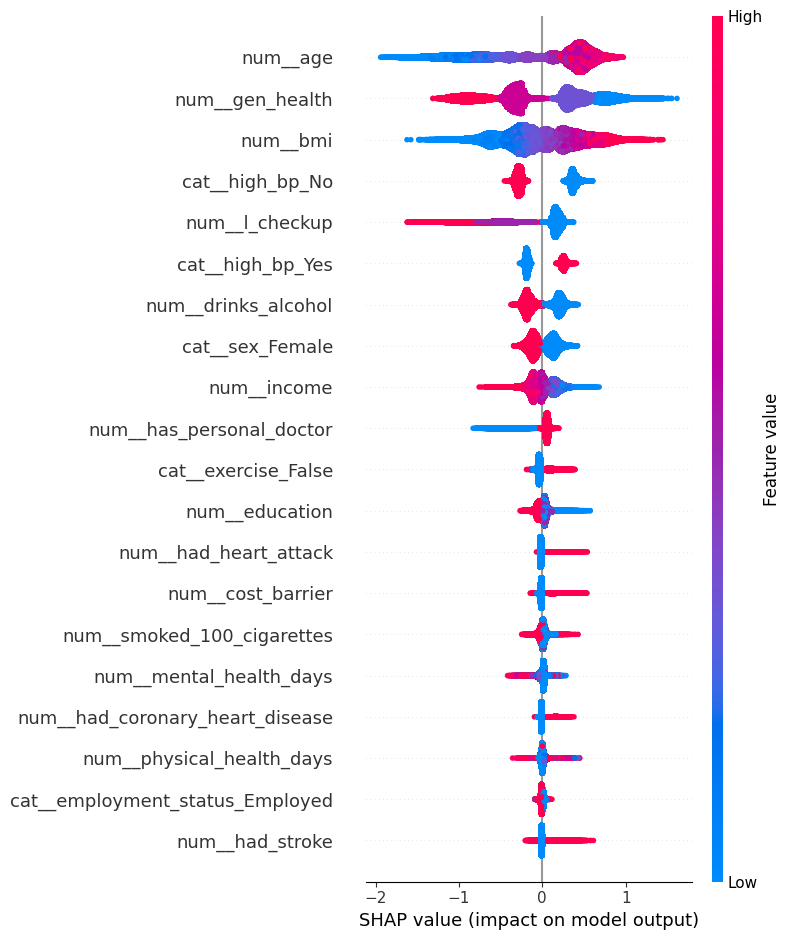

In [16]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

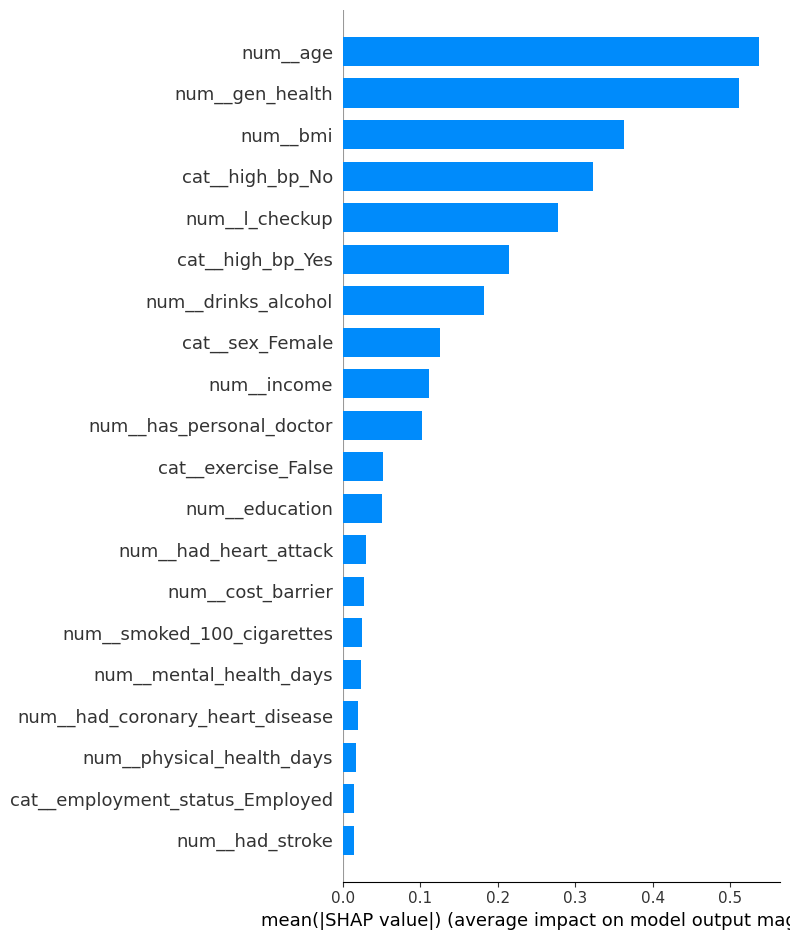

In [11]:
# SHAP bar plot
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_importance_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


['num__age' 'num__bmi' 'num__education' 'num__income' 'num__gen_health'
 'num__physical_health_days' 'num__mental_health_days'
 'num__smoked_100_cigarettes' 'num__drinks_alcohol' 'num__had_stroke'
 'num__had_heart_attack' 'num__had_coronary_heart_disease'
 'num__cost_barrier' 'num__l_checkup' 'num__has_personal_doctor'
 'cat__sex_Female' 'cat__sex_Male'
 'cat__marital_status_Married/Cohabiting'
 'cat__marital_status_Previously Married' 'cat__marital_status_Single'
 'cat__employment_status_Employed' 'cat__employment_status_Retired'
 'cat__employment_status_Student/Homemaker'
 'cat__employment_status_Unable to work'
 'cat__employment_status_Unemployed' 'cat__exercise_False'
 'cat__exercise_True' 'cat__high_bp_Borderline' 'cat__high_bp_No'
 'cat__high_bp_Yes']


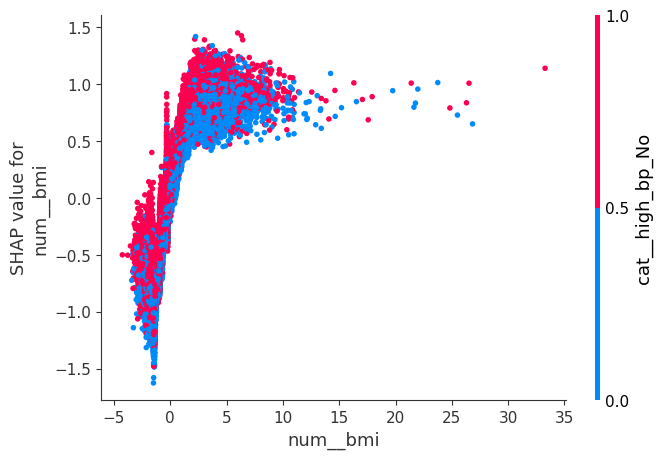

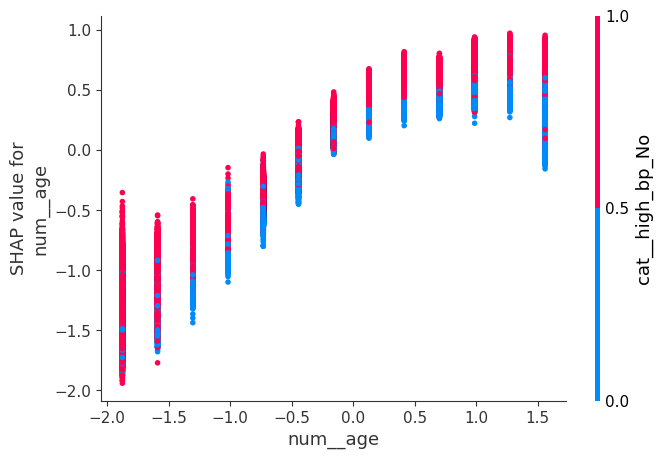

In [14]:
# Optional: Dependence Plots
# Replace names with actual feature names from your output

print(feature_names)

shap.dependence_plot(
    "num__bmi",
    shap_values,
    X_transformed,
    feature_names=feature_names
)

shap.dependence_plot(
    "num__age",
    shap_values,
    X_transformed,
    feature_names=feature_names
)

In [19]:
# check and compare model coefs for LogReg
logreg = joblib.load("../models/logreg_model.pkl")
print(logreg.named_steps)
logreg

{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'bmi', 'education', 'income',
                                  'gen_health', 'physical_health_days',
                                  'mental_health_days', 'smoked_100_cigarettes',
                                  'drinks_alcohol', 'had_stroke',
                                  'had_heart_attack',
                                  'had_coronary_heart_disease', 'cost_barrier',
                                  'l_checkup', 'has_personal_doctor']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'marital_status', 'employment_status',
                                  'exercise', 'high_bp'])]), 'xgb': LogisticRegression(C=0.01)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [20]:
logreg_model = logreg.named_steps["xgb"] #xgb here is a misnomer
logreg_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mu

In [21]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": logreg_model.coef_[0]
}).sort_values("coef", key=abs, ascending=False)
coef_df

,feature,coef
0,num__age,0.489353
4,num__gen_health,-0.481467
1,num__bmi,0.400474
28,cat__high_bp_No,-0.393811
13,num__l_checkup,-0.357539
29,cat__high_bp_Yes,0.349524
8,num__drinks_alcohol,-0.214697
14,num__has_personal_doctor,0.156473
23,cat__employment_status_Unable to work,0.154606
15,cat__sex_Female,-0.150489


This seems to be fairly consistent with the SHAP explainer as well.